This notebook will create the basic "counting and types" figure which also will show the plot-type accuracy plots.

In [55]:
main_llm_dir = '/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/'

# low-tier
low_dirs_to_use = ['chatgpt_api/', 'gemini/', 'claude_haiku/']

# mid-to-high tier
#midHigh_dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking/', 'chatgpt_api_highR_lowVerbose_mini/']
midHigh_dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking_maxT8000/', 'chatgpt_api_highR_lowVerbose_mini/']


# full baseline data stored
dir_jsons = '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/qa_jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/jcdl_followup/paper_figures/'

In [56]:
from sys import path
path.append('../')

import matplotlib.pyplot as plt
from importlib import reload
from copy import deepcopy
import numpy as np
import pandas as pd
import seaborn as sns

import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks

reload(utils.results_plotting_utils)
from utils.results_plotting_utils import add_kde_contours

import utils.replace_names_utils
reload(utils.replace_names_utils)
from utils.replace_names_utils import replace_names

dirs_to_use = deepcopy(low_dirs_to_use)
dirs_to_use.extend(midHigh_dirs_to_use)

In [57]:
def make_question_tags():
    df_question_tags = {}
    for t in ['tag', 'question', 'Level', 'Type']:
        df_question_tags[t] = []
    return df_question_tags

In [58]:
import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import get_dirs_names_files

dirnames, dirs, files_parsed = get_dirs_names_files(main_llm_dir, 
        dirs_to_use, 
        replace_names = replace_names,
        verbose=True)

DIRS:
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet_maxtoken8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_mini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_old
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking_maxT8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini

ONLY USED DIRNAMES, DIRS
GPT ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api/
Gemini ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini/
Claude ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku

In [59]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files, fix_aspect

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=False, use_explanation=True)
print("!!!!!!!! DONE LOADING !!!!!!!!!!!")

[ERROR]: different types of values, could not fix:
  GT: 855749.1277505575 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 4.561426392275432 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -818.4977275064518 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 19416132.33937408 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 5.534922356901159 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -60.00537889895291 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -59.60426621286831 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ER

<unknown>:1: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'


[ERROR]: different types of values, could not fix:
  GT: 135.0703267885132 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 116.44542286828813 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 105.2835618283954 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 17520347215890.066 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 4361323308289.718 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -263.69179358271674 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: 1385.3350403983563 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""

<unknown>:1: SyntaxWarning: invalid escape sequence '\c'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\_'


[ERROR]: different types of values, could not fix:
  GT: -305660.6534742053 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -58.959594910670056 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -58.73660626981654 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median y": ""}

[ERROR]: different types of values, could not fix:
  GT: 166.763705553173 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 5656.2030319162595 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 394989.4245753032 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -66.39066830315112 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERRO

<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\g'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\O'
<unknown>:1: SyntaxWarning: invalid escape sequence '\O'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\_'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:2: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: inv

[ERROR]: different types of values, could not fix:
  GT: -249349.01704986204 <class 'float'>
  LLM: Unable to determine from visible labels <class 'str'>
  raw LLM: {"maximum color": "Unable to determine from visible labels"}

[ERROR]: different types of values, could not fix:
  GT: -513215.2147431419 <class 'float'>
  LLM: null <class 'str'>
  raw LLM: {"mean color": "null"}

[ERROR]: different types of values, could not fix:
  GT: -857456.5832552586 <class 'float'>
  LLM: Unable to determine from image <class 'str'>
  raw LLM: {"minimum color": "Unable to determine from image"}

[ERROR]: different types of values, could not fix:
  GT: 130.54067743578003 <class 'float'>
  LLM: Unable to determine <class 'str'>
  raw LLM: {"mean color": "Unable to determine"}

!!!!!!!! DONE LOADING !!!!!!!!!!!


In [60]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
0,Picture_000037_qa,NaN,None,How many panels are in this figure?,False,GPT,gpt-5.4-nano-2026-03-17,"{'nrows': 4, 'ncols': 2}","{'nrows': 3, 'ncols': 2}",Level 1,Figure-level questions,{'explanation': 'The figure is arranged as a 4...
1,Picture_000037_qa,NaN,None,What is the plot style used in this figure?,False,GPT,gpt-5.4-nano-2026-03-17,{'plot style': 'classic'},{'plot style': 'seaborn-v0_8-notebook'},Level 1,Figure-level questions,{'explanation': 'The figure uses the default M...
2,Picture_000037_qa,NaN,None,What is the colormap that was used in this fig...,False,GPT,gpt-5.4-nano-2026-03-17,{'colormap': 'jet'},{'colormap': 'turbo_r'},Level 1,Figure-level questions,{'explanation': 'The figure includes multiple ...
3,Picture_000037_qa,NaN,None,What is the aspect ratio of this figure?,False,GPT,gpt-5.4-nano-2026-03-17,{'aspect ratio': 0.8},{'aspect ratio': 1.4068531722910849},Level 1,Figure-level questions,{'explanation': 'The image shows a 2×3 grid of...
4,Picture_000037_qa,NaN,None,What are the titles for each figure panel?,False,GPT,gpt-5.4-nano-2026-03-17,"{'titles': ['', 'PROFILE PROJECT 4', 'd_{iso} ...","{'titles': ['', '', 'AREAS ROUTINES LOBES CORR...",Level 1,Figure-level questions,{'explanation': 'I looked for titles/annotatio...


In [61]:
question_npanels = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'}
]

question_nbars = [
    {'tag':'# bars', 'question':'How many bars are there in the specified figure panel?', 'type':'float', 'yfudge':10}
]

question_types = [
    {'tag':'plot type', 'question':'What are the plot types for each panel in the figure?', 'type':'binary string list', 'use list':True, 'use bar':True}
]

In [62]:
# get low/high subsets
low_models = []
high_models = []
for k,v in replace_names.items():
    if k+'/' in low_dirs_to_use:
        low_models.append(v)
    elif k+'/' in midHigh_dirs_to_use:
        high_models.append(v)
low_models, high_models

(['GPT', 'Gemini', 'Claude'], ['GPT-HR', 'GPT-HRM', 'Claude-T'])

In [63]:
# get dataframes for each plot
reload(utils.results_plotting_utils)
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt
from utils.results_plotting_utils import calculate_plot_accuracies

# per panel
qtags = make_question_tags()
q_combo = deepcopy(question_npanels)
q_combo.extend(question_types)
_, df_low = calculate_plot_accuracies(df[df['model'].isin(low_models)],q_combo, qtags)
qtags = make_question_tags()
_, df_high = calculate_plot_accuracies(df[df['model'].isin(high_models)],q_combo, qtags)

# # number of bars
# qtags = make_question_tags()
# _, dfbars_low = calculate_plot_accuracies(df[df['model'].isin(low_models)],question_nbars, qtags)
# qtags = make_question_tags()
# _, dfbars_high = calculate_plot_accuracies(df[df['model'].isin(high_models)],question_nbars, qtags)

In [64]:
# q_combo

In [65]:
count_cut = 2

# for number of panels, cut each
dfpsort = df_low['# panels GT'].value_counts().sort_index()
panels_cut = dfpsort[dfpsort >= count_cut].index
print('only these panels:', np.array(panels_cut.values))

dfcut_low = df_low.copy()
dfcut_low = dfcut_low[dfcut_low['# panels GT'].isin(panels_cut)]

# for number of panels, cut each
dfpsort = df_high['# panels GT'].value_counts().sort_index()
panels_cut = dfpsort[dfpsort >= count_cut].index
print('only these panels:', np.array(panels_cut.values))

dfcut_high = df_high.copy()
dfcut_high = dfcut_high[dfcut_high['# panels GT'].isin(panels_cut)]


only these panels: [ 1  2  3  4  5  6  8  9 12 15]
only these panels: [ 1  2  3  4  5  6  8  9 12 15]


In [66]:
dfcut_low.head(n=2)

,Tag,# panels GT,GPT # panels,Gemini # panels,Claude # panels,GPT plot type,Gemini plot type,Claude plot type
0,# panels,6,8,9,6,1.0,1.0,0.666667
1,# panels,1,36,1,1,0.0,1.0,0.000000


In [67]:
dfcut_high.head(n=2)

,Tag,# panels GT,GPT-HR # panels,Claude-T # panels,GPT-HRM # panels,GPT-HR plot type,Claude-T plot type,GPT-HRM plot type
0,# panels,6,6,6,6,1.0,1.0,1.0
1,# panels,1,42,1,1,0.0,0.0,1.0


In [68]:
# create model order
model_order = []  # adjust to your model names
for d in dirs_to_use:
    model_order.append(replace_names[d.replace('/','')])
model_order

['GPT', 'Gemini', 'Claude', 'GPT-HR', 'Claude-T', 'GPT-HRM']

In [69]:
marker_min = 20
marker_max = 50

# markers
colors_levels_low = ['darkblue', 'orange', 'cyan']
marker_sizes_low, marker_styles_low, \
    colors_low, labels_low = create_output_marks(df[df['model'].isin(low_models)], 
    marker_min=marker_min, marker_max=marker_max, 
    colors_levels=colors_levels_low)

colors_levels_high = ['red', 'gold', 'magenta']
marker_sizes_high, marker_styles_high, \
    colors_high, labels_high = create_output_marks(df[df['model'].isin(high_models)], 
    marker_min=marker_min, marker_max=marker_max, 
    colors_levels=colors_levels_high)

/var/folders/1c/xcwp8_px05xg1_3xd9nn9qhm0000gn/T/ipykernel_14942/4170350376.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar_ax.set_ticklabels(cbar_ax.get_ticks(), fontsize=cbar_tick_fontsize)


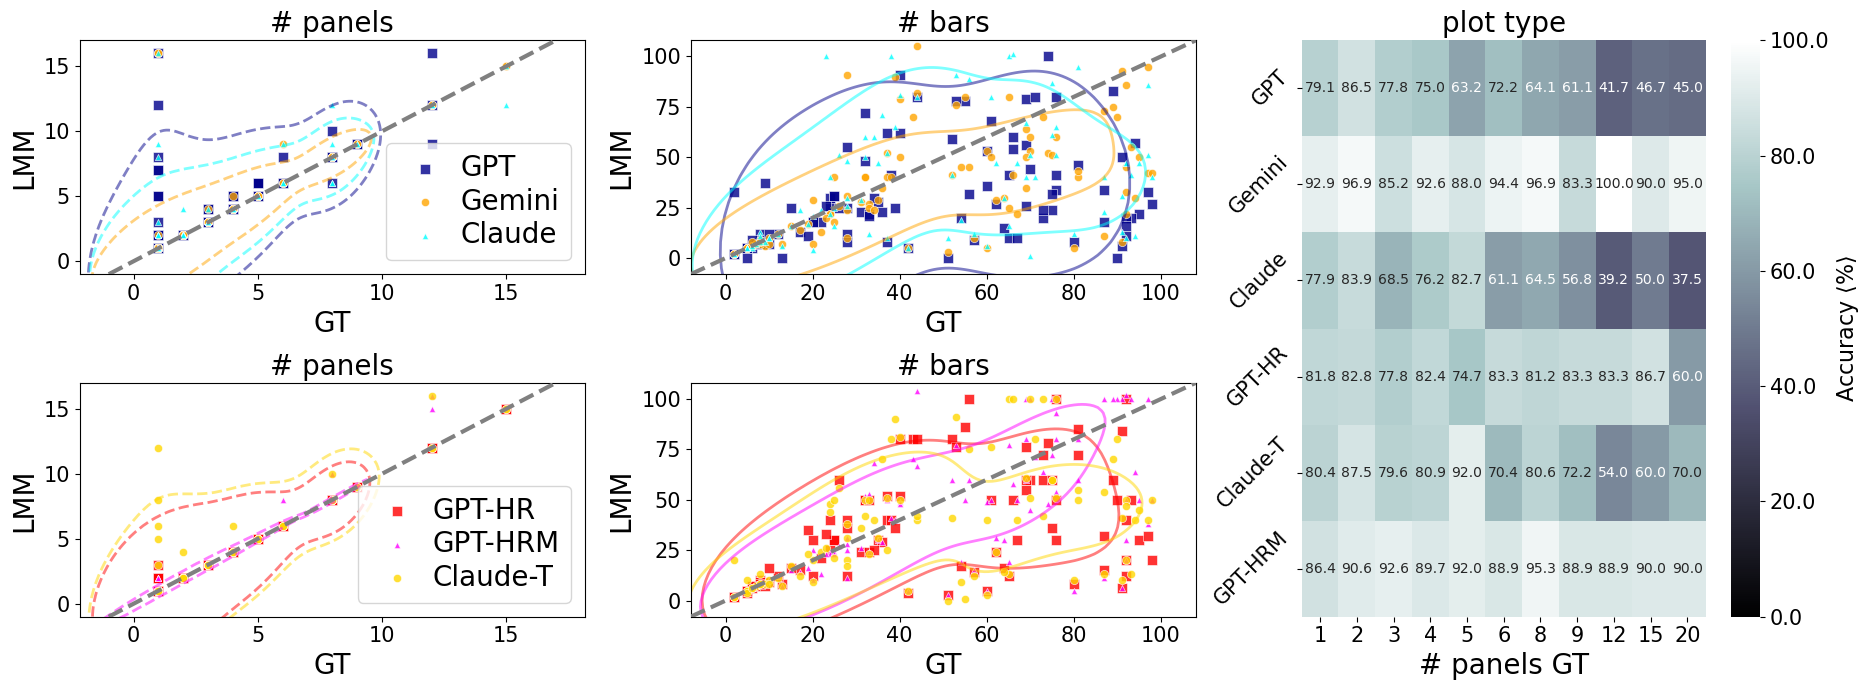

In [70]:
base = 7
fac = 0.9

fig, axes = plt.subplot_mosaic([['low-npanels', 'low-nbars', 'heatmap'],
                                 ['high-npanels', 'high-nbars', 'heatmap']], 
                                 figsize=(base*3*fac, base))



fontsize = 20
tick_fontsize = 15
legend_fontsize = 20
barfontsize = 16
cbar_tick_fontsize = 15
annot_fontsize = 10
#annot_fmt = '.1f'
annot_fmt = '.0f' # whole numbers

handletextpad=0.3
labelspacing=0.2

legend_loc = None

fudge = 2
levels = {'npanels':[0.1], 'nbars':[0.5]}
plot_kde = True
eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'
cmap = 'bone'
plot_diffs = False
normalize_diff = False
take_abs = True

# get sub for low/high
#dfplot = dfcut_low
q = question_npanels[0]



iq = 0
gttag = '# panels GT' # for fixed axis
fixed_axis = '# panels GT'

for modeltype, labels, colors, marker_styles, marker_sizes, dfplot, name in zip([low_models, high_models], 
                                                                                [labels_low,labels_high],
                                                                                [colors_low,colors_high], 
                                                                                [marker_styles_low,marker_styles_high],
                                                                                [marker_sizes_low,marker_sizes_high],
                                                                                [dfcut_low,dfcut_high],
                                                                                ['low','high']):

    for model in modeltype:
        lmtag = labels[model] + ' ' + q['tag'] 
        if 'yfudge' not in q:
            q = deepcopy(q)
            q['yfudge'] = fudge
        if 'xfudge' not in q:
            q['xfudge'] = fudge
        gt = dfplot[gttag]
        lmm = dfplot[lmtag]

        add_kde_contours(axes[name+'-npanels'], gt, lmm, colors[model], 
                                        labels[model], marker_styles[model], marker_sizes[model], 
                                        levels=levels['npanels'], plot_kde=plot_kde, linestyle=['--'])
    axes[name+'-npanels'].legend(fontsize=legend_fontsize, loc=legend_loc, handletextpad=handletextpad, labelspacing=labelspacing)
    # axes[name+'-npanels'].legend(handletextpad=handletextpad, labelspacing=labelspacing)  # labelspacing controls vertical gap between entries
    axes[name+'-npanels'].plot([np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge']], 
                            [np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge']], 
                            linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                            color=eq_linecolor)
    axes[name+'-npanels'].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
    #axes[name+'-npanels'].set_ylabel(name.capitalize() + '-level LMM' + gttag.removesuffix(' GT'))
    # labels
    axes[name+'-npanels'].set_xlabel('GT', fontsize=fontsize)
    axes[name+'-npanels'].set_ylabel('LMM', fontsize=fontsize)
    axes[name+'-npanels'].set_title(gttag.removesuffix(' GT'), fontsize=fontsize)



####### now for counting number of bars #######
q = question_nbars[0]
for modeltype, labels, colors, marker_styles, marker_sizes, name in zip([low_models, high_models], 
                                                                                [labels_low,labels_high],
                                                                                [colors_low,colors_high], 
                                                                                [marker_styles_low,marker_styles_high],
                                                                                [marker_sizes_low,marker_sizes_high],
                                                                                ['low','high']):

    # sub for question and model type
    dfsub = df[(df['question']==q['question']) & (df['model'].isin(modeltype))]

    for model in modeltype:
        dfsub2 = dfsub[dfsub['model']==model]
        gt, lmm1 = get_lmm_gt(dfsub2, q['type'],verbose=False)
        gttag = q['tag']+' GT'
        lmtag = labels[model]
        lmtag = labels[model] + ' ' + q['tag'] 
        lmm = deepcopy(lmm1)

        add_kde_contours(axes[name+'-nbars'], gt, lmm, colors[model], 
                                        None, marker_styles[model], marker_sizes[model], 
                                        levels=levels['nbars'], plot_kde=plot_kde)
    axes[name+'-nbars'].plot([np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge']], 
                            [np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge']], 
                            linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                            color=eq_linecolor)
    axes[name+'-nbars'].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
    axes[name+'-nbars'].set_xlim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
    # labels
    axes[name+'-nbars'].set_xlabel('GT', fontsize=fontsize)
    #axes[name+'-nbars'].set_ylabel(name.capitalize() + '-level LMM' + gttag.removesuffix(' GT'))
    axes[name+'-nbars'].set_ylabel('LMM', fontsize=fontsize)
    axes[name+'-nbars'].set_title(gttag.removesuffix(' GT'), fontsize=fontsize)



############### for plot types ##############
counts_df = {}
labels = deepcopy(labels_low)
for k,v in labels_high.items():
    labels[k] = v

dfin = pd.concat([df_low,df_high])
q = question_types[0]
counts_df[q['tag']] = {'use bar':False, 'df':{}, 'panel':-1}
models = deepcopy(low_models)
models.extend(high_models)
dfplot = dfin

use_average_percent = True
ylabel_tag = 'LMM ' + q['tag']


for imodel, model in enumerate(models):
    lmtag = labels[model] + ' ' + q['tag'] 
    gttag = q['tag'] + ' GT'
    if fixed_axis is not None:
        gttag = fixed_axis
    if 'yfudge' not in q:
        q = deepcopy(q)
        q['yfudge'] = fudge
    if 'xfudge' not in q:
        q['xfudge'] = fudge
    gt = dfplot[gttag]
    lmm = dfplot[lmtag]

    if 'string' in q['type']: # convert to %
        lmm *= 100
        if not use_average_percent:
            ylabel_tag += ' [%]'
        else:
            ylabel_tag += ' <[%]>'
            lmm = dfplot.groupby(gttag)[lmtag].mean().reset_index()[lmtag]
            gt = dfplot.groupby(gttag)[lmtag].mean().reset_index()[gttag]
            if 'use bar' in q:
                if q['use bar']:
                    counts_df[q['tag']]['use bar'] = True
                    counts_df[q['tag']]['panel'] = iq
                    useBar = True
                    for cname in ['Model', gttag, 'Accuracy <[%]>']:
                        if cname not in counts_df[q['tag']]['df']:
                            counts_df[q['tag']]['df'][cname] = []
                    counts_df[q['tag']]['df']['Model'].extend(np.repeat(model,len(gt)))
                    counts_df[q['tag']]['df'][gttag].extend(deepcopy(gt))
                    counts_df[q['tag']]['df']['Accuracy <[%]>'].extend(deepcopy(lmm))


# go back and plot all models-things
# dfplot = df_low.copy()
#dfplot = pd.concat([df_low,df_high])
acctag = r'Accuracy $\mathrm{\langle \% \rangle}$' #CER <[%]>'

for k,d in counts_df.items():
    if d['use bar']:
        dfc = pd.DataFrame(d['df'])
        cgt = dfc.columns[~dfc.columns.isin(['Model','Accuracy <[%]>'])][0]
        pivot = dfc.pivot(index='Model', columns=cgt, values='Accuracy <[%]>')
        pivot = pivot.reindex(model_order)
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, 
            vmin=0, vmax=100, ax=axes['heatmap'], annot_kws={'size': annot_fontsize})
        axes['heatmap'].set_yticklabels(axes['heatmap'].get_yticklabels(), 
                                 rotation=45, ha='right', va='center')
        axes['heatmap'].set_ylabel('LMM '+k)
        cbar_ax = axes['heatmap'].collections[0].colorbar
        # cbar.set_label('Accuracy <[%]>', fontsize=12, labelpad=10)
        cbar_ax.set_label(acctag, fontsize=barfontsize)#, labelpad=barpad)
        cbar_ax.set_ticklabels(cbar_ax.get_ticks(), fontsize=cbar_tick_fontsize)

# plot type
axes['heatmap'].set_title('plot type', fontsize=fontsize)
axes['heatmap'].set_ylabel('')                       # remove "Model" y-axis label
axes['heatmap'].set_xlabel(gttag, fontsize=fontsize)


# set font sizes
for k,ax in axes.items():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

fig.tight_layout()

fig.savefig(save_fig_dir + 'simple_count_and_type.pdf')

In [71]:
ax

<Axes: label='high-nbars', title={'center': '# bars'}, xlabel='GT', ylabel='LMM'>

In [72]:
cbar_ax.get_ticks

<bound method Colorbar.get_ticks of <matplotlib.colorbar.Colorbar object at 0x322704a70>>